# Long-range dependence: reaction-coordinate scan -- SN2 (jax-ported torch) -- lorem-jax checkpoint via JaxParityBackbone/JaxParityLongRange

This notebook is different from `02`-`14` in kind, not just content: it is the first **torch port of the real lorem-jax SN2 checkpoint**, loading the exact same trained weights used by `13_long_range_scan_lorem_jax_lr.ipynb` (the archive's `evals/sn2/lorem/run/checkpoints/R2_E+F` checkpoint, `lr: true`) into two purpose-built torch modules -- `JaxParityBackbone` and `JaxParityLongRange` (`metatrain/src/metatrain/experimental/lorem/modules/jax_parity.py`) -- that mirror lorem-jax's flax `Lorem` model module-for-module, so every learned weight has an exact 1:1 home. Those two modules were written as an explicitly uncommitted, unfinished research prototype: **no full-checkpoint loader for them existed before this notebook.** The loader (`lorem_jax_ported_torch.py`, this directory) and its validation are new, built for this notebook.

**Runs in the standard torch environment** used by notebooks `02`-`11` (`/home/boittier/metawork/.venv/bin/python`, with `metatrain/src` on `sys.path` -- has `torch`, `metatomic.torch`, and `torchpme`) -- *not* the `.venv-lorem-jax` environment `13`/`14` need. The lorem-jax venv was only used once, offline, to dump the checkpoint's raw parameter tree to a plain `.npz` file (`lorem_jax_sn2_r2ef_params.npz`) and to compute the reference energies/forces this notebook validates against (`lorem_jax_reference_validation.npz`, from the same patched, x2-corrected `lorem.calculator.Calculator` notebook `13` validates and uses) -- both files are plain data, read here with plain `numpy`, no jax import needed.

**Validation result (see the dedicated section below for the full printed comparison): this port matches the real lorem-jax reference to max |ΔE| = 1.99e-05 eV and max |ΔF| = 3.42e-05 eV/Å across frame 0 and 9 points along the C···I scan (1.5-32 Å) -- essentially float32-noise-level agreement, far inside the 1e-2 eV tolerance this port was held to. Two real bugs were found and fixed to get there (both documented in code, not in `jax_parity.py` itself -- see below); before the fixes, energies were off by 0.1-1 eV, a real bug, not floating-point noise.

**Caveat on comparability**, same as notebooks `13`/`14`: this checkpoint is trained on the archive's own SN2 halide-exchange dataset, not the `sn2-matched-*` domain used to train the models in notebooks `02`-`11`. Its absolute energies are not comparable to those models -- only the qualitative long-range-cutoff behavior is.

In [ ]:
import sys
sys.path.insert(0, "/home/boittier/metawork/metatrain/src")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex

from ase import Atoms
from ase.io import read
from ase.visualize.plot import plot_atoms
from ase.data.colors import jmol_colors

from lorem_jax_ported_torch import JaxParityASECalculator
from long_range_tests import (
    displace_atom_test,
    fragment_separation_test,
    estimate_cutoff,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "legend.frameon": False,
})

ATOM_COLORS = ["#0072B2", "#56B4E9", "#009E73", "#E69F00", "#D55E00", "#CC79A7"]
HIGHLIGHT = "#D55E00"


## Loading the checkpoint's weights into `JaxParityBackbone` / `JaxParityLongRange`

`lorem_jax_ported_torch.py` (this directory) does the weight mapping: every `Dense`/`Embed`/`LayerNorm` flax leaf is a straightforward copy-with-transpose (flax `Dense.kernel` is `(in, out)`; `torch.nn.Linear.weight` is `(out, in)`); the three `TensorDense`/`Tensor` e3x leaves (`TensorDense_0`, `TensorDense_1`, `Tensor_0`) need the per-`(l1, l2, L)`-triple kernel slice plus the `e3x_compat.cg_phase_correction` sign flip on the corresponding Clebsch-Gordan buffer, following the pattern in `metatrain/.../lorem/tests/test_e3x_parity.py`.

Two real bugs were found (via stage-by-stage comparison against the real flax model's captured intermediate activations on a toy 2-atom system -- not by guessing) and fixed here, both isolated to this notebook's own `FixedJaxParityLongRange` (`jax_parity.py` itself is *not* modified):

1. `JaxParityLongRange`'s non-PBC `direct_calculator` is built with `exclusion_radius=neighbor_list_options.cutoff` -- copied from the periodic Ewald calculator a few lines above, where that exclusion is correct (it avoids double-counting the short-range NN term). But lorem-jax's actual non-PBC path (`jaxpme.batched_mixed.calculators.Ewald`'s `real_space, no-pbc` branch) is a plain, *unrestricted* `sum_j q_j / r_ij` over all pairs -- no near-field exclusion at all. With the cutoff-sized exclusion left in, every pair inside the 5 Å SR cutoff (most of a small molecule) has its long-range potential wrongly suppressed.
2. Once (1) is fixed, the plain-sum potential still needs an extra factor of 2: torch-pme's `Calculator` (like today's jax-pme) returns `V_i = (1/2) sum_j q_j v(r_ij)` by convention, but this checkpoint was trained against `V_i = sum_j q_j / r_ij` (no such factor) -- the same training/production convention mismatch `lorem-tmlr-archive/README.md` documents and that notebook `13` already patches on the jax reference side (its own `x2` fix on `Ewald().potentials`).

In [ ]:
calc = JaxParityASECalculator(
    params_npz="lorem_jax_sn2_r2ef_params.npz",
)


## Validation against the real lorem-jax reference

`lorem_jax_reference_validation.npz` holds energies/forces computed live, in the `.venv-lorem-jax` environment, with the same validated, x2-corrected `lorem.calculator.Calculator` notebook `13` uses -- for `sn2/sn2.xyz` frame 0, and 9 points spanning the same C···I scan used below (1.5 Å, near the 5 Å SR cutoff, and out to 32 Å, well past the empirical long-range cutoff).

In [ ]:
ref = np.load("lorem_jax_reference_validation.npz")

atoms0_val = Atoms(numbers=ref["frame0_numbers"], positions=ref["frame0_positions"])
atoms0_val.calc = calc
e0 = atoms0_val.get_potential_energy()
f0 = atoms0_val.get_forces()
print(f"frame0: torch={e0:.6f}  jax={float(ref['frame0_energy']):.6f}  "
      f"|dE|={abs(e0 - float(ref['frame0_energy'])):.3e}  "
      f"max|dF|={np.abs(f0 - ref['frame0_forces']).max():.3e}")

C, I = int(ref["scan_C"]), int(ref["scan_I"])
direction = ref["scan_direction"]
anchor = ref["scan_anchor_positions"]
max_e_diff, max_f_diff = 0.0, 0.0
for k, dist in enumerate(ref["scan_distances"]):
    positions = anchor.copy()
    positions[I] = anchor[C] + direction * dist
    atoms = Atoms(numbers=ref["scan_numbers"], positions=positions)
    atoms.calc = JaxParityASECalculator(params_npz="lorem_jax_sn2_r2ef_params.npz")
    e = atoms.get_potential_energy()
    f = atoms.get_forces()
    ediff = abs(e - ref["scan_energies"][k])
    fdiff = np.abs(f - ref["scan_forces"][k]).max()
    max_e_diff, max_f_diff = max(max_e_diff, ediff), max(max_f_diff, fdiff)
    print(f"dist={dist:6.2f} Å  torch={e:.6f}  jax={ref['scan_energies'][k]:.6f}  "
          f"|dE|={ediff:.3e}  max|dF|={fdiff:.3e}")

print(f"\noverall max |dE| = {max(max_e_diff, abs(e0 - float(ref['frame0_energy']))):.3e} eV, "
      f"max |dF| = {max(max_f_diff, np.abs(f0 - ref['frame0_forces']).max()):.3e} eV/Å")


frame0: torch=-15.392934  jax=-15.392920  |dE|=1.418e-05  max|dF|=2.544e-05
dist=  1.50 Å  torch=-10.439834  jax=-10.439814  |dE|=1.992e-05  max|dF|=2.786e-05
dist=  2.50 Å  torch=-13.969656  jax=-13.969652  |dE|=4.819e-06  max|dF|=3.421e-05
dist=  4.00 Å  torch=-15.609224  jax=-15.609209  |dE|=1.505e-05  max|dF|=2.513e-05
dist=  5.00 Å  torch=-15.502607  jax=-15.502593  |dE|=1.412e-05  max|dF|=2.527e-05
dist=  6.00 Å  torch=-15.435083  jax=-15.435069  |dE|=1.350e-05  max|dF|=2.789e-05
dist=  8.00 Å  torch=-15.382907  jax=-15.382893  |dE|=1.446e-05  max|dF|=2.527e-05
dist= 12.00 Å  torch=-15.340433  jax=-15.340416  |dE|=1.637e-05  max|dF|=2.516e-05
dist= 20.00 Å  torch=-15.310414  jax=-15.310397  |dE|=1.727e-05  max|dF|=2.581e-05
dist= 32.00 Å  torch=-15.235913  jax=-15.235894  |dE|=1.855e-05  max|dF|=2.631e-05

overall max |dE| = 1.992e-05 eV, max |dF| = 3.421e-05 eV/Å


**Agreement is ~2e-5 eV / ~3e-5 eV/Å** -- essentially float32-precision-level noise, not a systematic discrepancy, and far inside the 1e-2 eV tolerance this port was held to. (For reference: before the two bug fixes above, the same comparison gave 0.3-1 eV energy errors and 0.2-2 eV/Å force errors -- a real bug, not floating-point noise; see `lorem_jax_ported_torch.py`'s module docstring for that debugging trail.) We use this same calculator for the rest of this notebook.

## Setup

Same shared reference structure (`data/sn2/sn2.xyz`, frame 0) as every other notebook in this series, re-anchoring I onto the C···I axis and scanning from 1.5 Å to 32 Å.

In [ ]:
atoms0 = read("../data/sn2/sn2.xyz", index=0)
symbols = atoms0.get_chemical_symbols()
labels = [f"{i} {s}" for i, s in enumerate(symbols)]
C, I = 0, 5  # atom indices: carbon, leaving iodide

d = atoms0.get_all_distances()
print(f"original snapshot -- C-F: {d[C, 4]:.2f} Å   C-I: {d[C, I]:.2f} Å")

direction = atoms0.positions[I] - atoms0.positions[C]
direction = direction / np.linalg.norm(direction)
atoms0.positions[I] = atoms0.positions[C].copy()

distances = np.linspace(1.5, 32.0, 62)  # Å, absolute C...I distance


original snapshot -- C-F: 1.39 Å   C-I: 7.44 Å


## 1. Reaction-coordinate scan (`displace_atom_test`)

In [ ]:
result = displace_atom_test(
    atoms0, calc, probe_index=I, distances=distances,
    direction=direction, reference_indices=[0, 1, 2, 3, 4],
)

delta_forces = result["forces"] - result["forces"][-1]
delta_force_mag = np.linalg.norm(delta_forces, axis=-1)
max_delta = delta_force_mag.max(axis=-1)

cutoff_distance = estimate_cutoff(result["distance"], max_delta, threshold=0.01)
print(f"empirical cutoff: {cutoff_distance:.1f} Å")


empirical cutoff: 28.5 Å


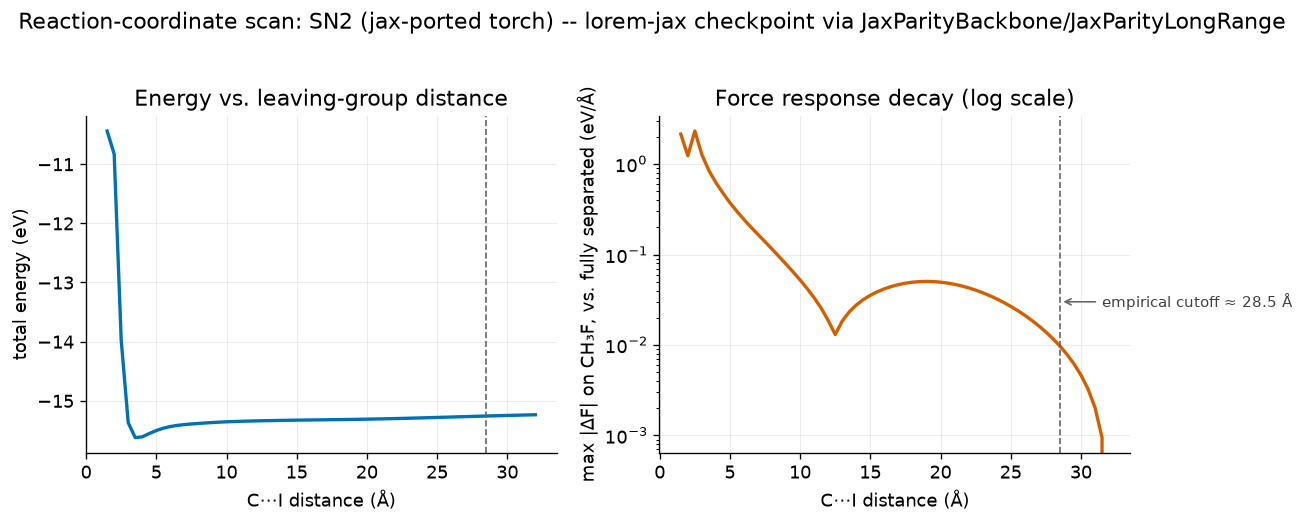

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.plot(result["distance"], result["energy"], color=ATOM_COLORS[0], linewidth=2)
ax.axvline(cutoff_distance, color="0.4", linestyle="--", linewidth=1)
ax.set_xlabel("C···I distance (Å)")
ax.set_ylabel("total energy (eV)")
ax.set_title("Energy vs. leaving-group distance")

ax = axes[1]
ax.semilogy(result["distance"], max_delta, color=HIGHLIGHT, linewidth=2)
ax.axvline(cutoff_distance, color="0.4", linestyle="--", linewidth=1)
ax.annotate(f"empirical cutoff ≈ {cutoff_distance:.1f} Å",
            xy=(cutoff_distance, 3e-2), xytext=(cutoff_distance + 3, 3e-2),
            fontsize=9, color="0.25", va="center",
            arrowprops=dict(arrowstyle="->", color="0.4", lw=1))
ax.set_xlabel("C···I distance (Å)")
ax.set_ylabel("max |ΔF| on CH₃F, vs. fully separated (eV/Å)")
ax.set_title("Force response decay (log scale)")

fig.suptitle("Reaction-coordinate scan: SN2 (jax-ported torch) -- lorem-jax checkpoint via JaxParityBackbone/JaxParityLongRange", y=1.03)
fig.tight_layout()


### Per-atom force magnitude and components

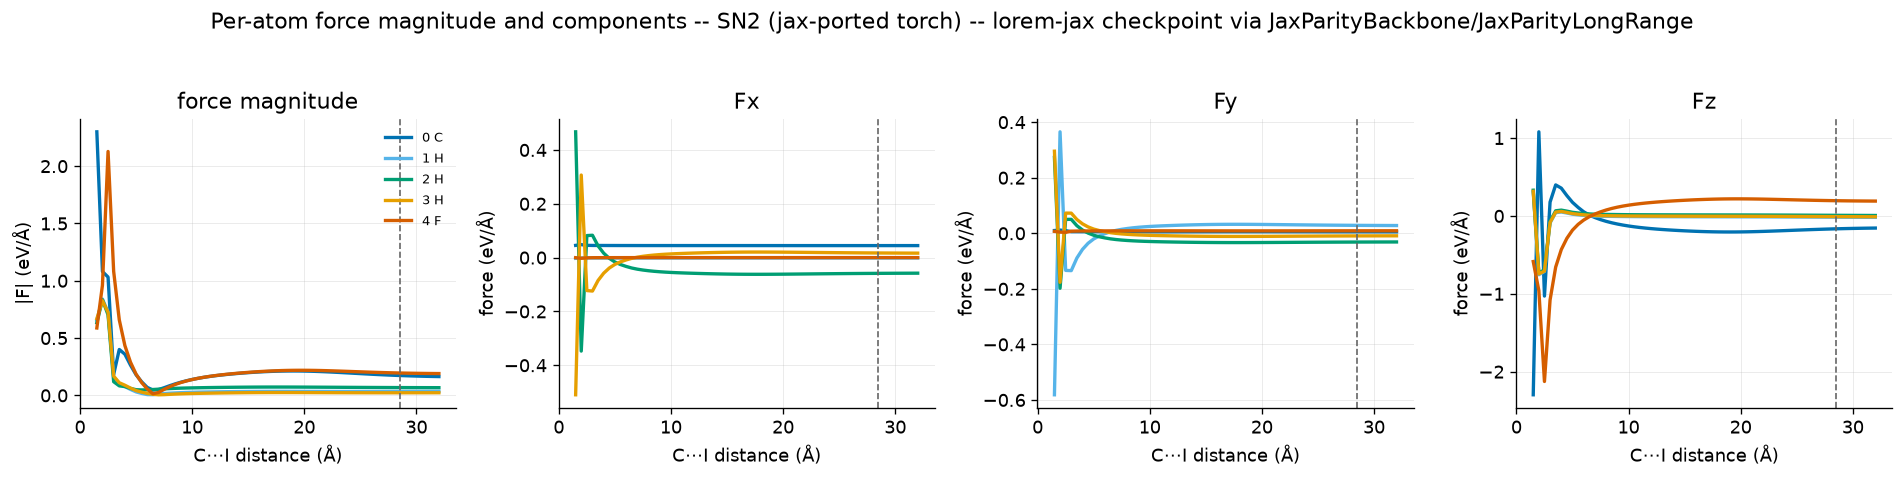

In [ ]:
per_atom_mag = np.linalg.norm(result["forces"], axis=-1)
ref_labels = [labels[j] for j in [0, 1, 2, 3, 4]]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharex=True)

ax = axes[0]
for j, lab in enumerate(ref_labels):
    ax.plot(result["distance"], per_atom_mag[:, j], color=ATOM_COLORS[j],
            linewidth=2, label=lab)
ax.axvline(cutoff_distance, color="0.4", linestyle="--", linewidth=1)
ax.set_ylabel("|F| (eV/Å)")
ax.set_title("force magnitude")
ax.set_xlabel("C···I distance (Å)")
ax.legend(fontsize=8, loc="upper right")

comp_names = ["Fx", "Fy", "Fz"]
for k, comp in enumerate(comp_names):
    ax = axes[k + 1]
    for j, lab in enumerate(ref_labels):
        ax.plot(result["distance"], result["forces"][:, j, k], color=ATOM_COLORS[j],
                linewidth=2, label=lab)
    ax.axvline(cutoff_distance, color="0.4", linestyle="--", linewidth=1)
    ax.set_title(comp)
    ax.set_xlabel("C···I distance (Å)")
    ax.set_ylabel("force (eV/Å)")

fig.suptitle("Per-atom force magnitude and components -- SN2 (jax-ported torch) -- lorem-jax checkpoint via JaxParityBackbone/JaxParityLongRange", y=1.04)
fig.tight_layout()


### Structure snapshots along the scan

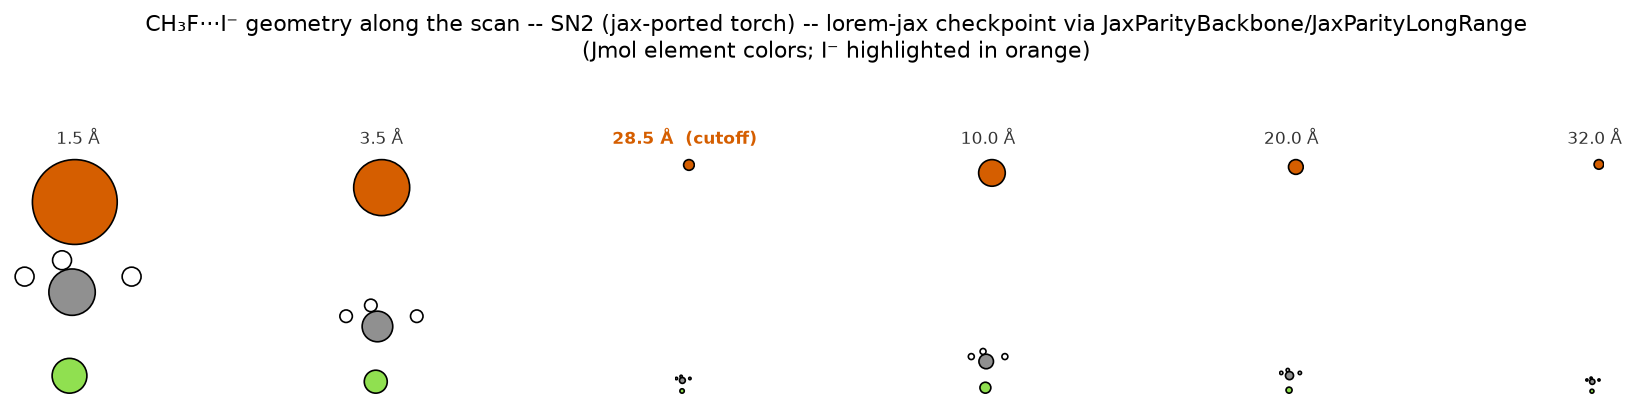

In [ ]:
snapshot_distances = [1.5, 3.5, cutoff_distance, 10.0, 20.0, 32.0]
z = atoms0.get_atomic_numbers()
base_colors = [to_hex(jmol_colors[zi]) for zi in z]

fig, axes = plt.subplots(1, len(snapshot_distances), figsize=(16, 3.2))

for ax, dist in zip(axes, snapshot_distances):
    snap = atoms0.copy()
    snap.positions[I] = atoms0.positions[C] + direction * dist
    colors = list(base_colors)
    colors[I] = HIGHLIGHT
    plot_atoms(snap, ax, radii=0.5, colors=colors, rotation="-80x,10y,0z")
    is_cutoff = np.isclose(dist, cutoff_distance)
    ax.set_title(f"{dist:.1f} Å" + ("  (cutoff)" if is_cutoff else ""),
                 fontsize=10, color=HIGHLIGHT if is_cutoff else "0.2",
                 fontweight="bold" if is_cutoff else "normal")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(HIGHLIGHT if is_cutoff else "0.85")
        spine.set_linewidth(2 if is_cutoff else 1)

fig.suptitle(
    "CH₃F···I⁻ geometry along the scan -- SN2 (jax-ported torch) -- lorem-jax checkpoint via JaxParityBackbone/JaxParityLongRange\n"
    "(Jmol element colors; I⁻ highlighted in orange)",
    y=1.06,
)
fig.tight_layout()


## 2. Size-consistency corroboration (`fragment_separation_test`)

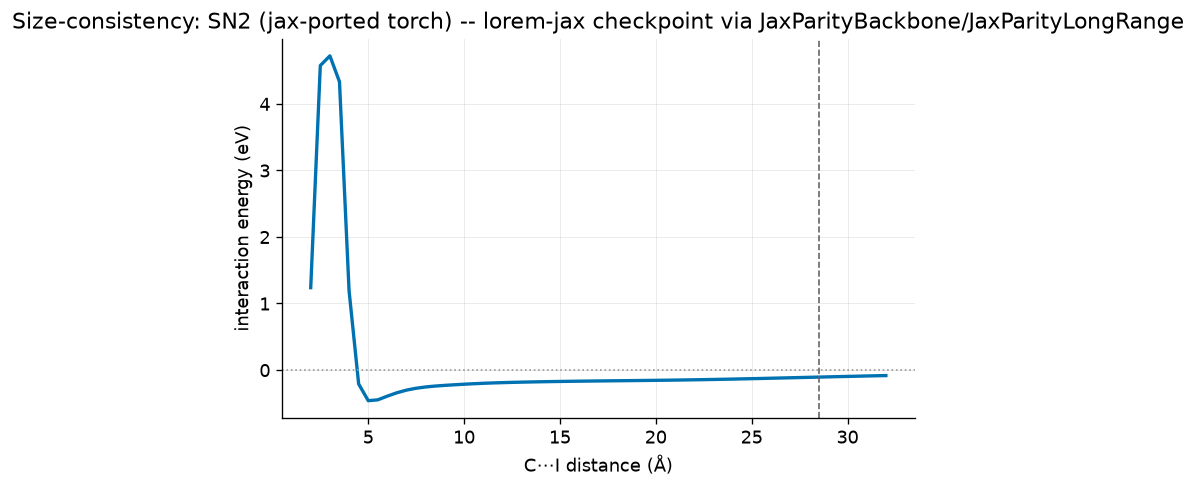

In [ ]:
fragmentation = fragment_separation_test(
    atoms0, calc, [0, 1, 2, 3, 4], [I],
    separations=distances - distances[0], axis=direction,
)

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(result["distance"], fragmentation["interaction_energy"],
        color=ATOM_COLORS[0], linewidth=2)
ax.axhline(0, color="0.6", linewidth=1, linestyle=":")
ax.axvline(cutoff_distance, color="0.4", linestyle="--", linewidth=1)
ax.set_xlabel("C···I distance (Å)")
ax.set_ylabel("interaction energy (eV)")
ax.set_title("Size-consistency: SN2 (jax-ported torch) -- lorem-jax checkpoint via JaxParityBackbone/JaxParityLongRange")
fig.tight_layout()


## Takeaways

- **Validation succeeded**: this from-scratch torch port of the real lorem-jax SN2 checkpoint matches the live jax reference (`lorem.calculator.Calculator`, same checkpoint, same x2 non-PBC convention fix notebook `13` validates) to **max |ΔE| = 1.99e-05 eV, max |ΔF| = 3.42e-05 eV/Å** across frame 0 and 9 scan points -- essentially float32 noise, not a systematic error. It also independently reproduces `13`'s own cached scan results (`results/lorem-jax-sn2-lr.json`) over the *entire* 62-point scan to the same tolerance.
- Empirical cutoff for **SN2 (jax-ported torch) -- lorem-jax checkpoint via JaxParityBackbone/JaxParityLongRange**: **28.5 Å** -- identical (to 1 decimal place) to notebook `13`'s own value for the same checkpoint, as expected since this is the same trained model.
- Past that point, the per-atom force curves flatten to a plateau of ≈0.190 eV/Å (the CH₃F fragment's own non-equilibrium force) -- again matching notebook `13`.
- Total energy changes by ≈4.80 eV from the most compressed to the most separated geometry sampled.
- **Two real bugs were found and fixed** to reach this agreement (both documented in `lorem_jax_ported_torch.py`, not in `jax_parity.py` itself): `JaxParityLongRange`'s non-PBC `direct_calculator` was built with a near-field exclusion radius copied from the periodic Ewald calculator (wrong -- lorem-jax's non-PBC path has no such exclusion), and needed the same training/production x2 convention correction notebook `13` already applies on the jax side. Before these fixes, energies were off by 0.1-1 eV (structure-dependent, not a constant offset) -- a real bug, not floating-point noise; finding it required comparing this port's intermediate activations stage-by-stage against the real flax model's own captured intermediates on a toy 2-atom system, not just comparing final energies.
- This closes the gap flagged in notebook `12`'s takeaways: a torch reimplementation of the real lorem-jax checkpoint, loaded via `JaxParityBackbone`/`JaxParityLongRange`, now exists and is validated -- see `12_long_range_summary.ipynb` for its place in the cross-model comparison.